<a href="https://colab.research.google.com/github/Semere-Mesfin-Gebresilassie/Semere-Mesfin-Gebresilassie/blob/main/Traffic_Accident_Severity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data Collection

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import Datasets(Road Traffic Accident)

In [ ]:
RTA = pd.read_csv(r'//content/RTA Dataset.csv')

In [ ]:
RTA.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [ ]:
# Data Preprocessing

In [ ]:
RTA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [ ]:
RTA.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [ ]:
print(RTA['Accident_severity'].value_counts())
#RTA['Accident_severity'].value_counts().plot(kind='bar')

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


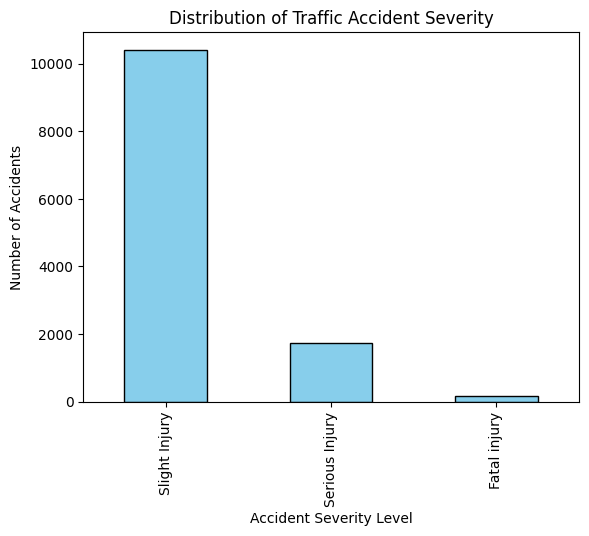

In [ ]:
#RTA['Accident_severity'].value_counts().plot(kind='bar')

# Plot the bar chart for accident severity counts
RTA['Accident_severity'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

# Add chart title and labels
plt.title('Distribution of Traffic Accident Severity')
plt.xlabel('Accident Severity Level')
plt.ylabel('Number of Accidents')

# Display the chart
plt.show()

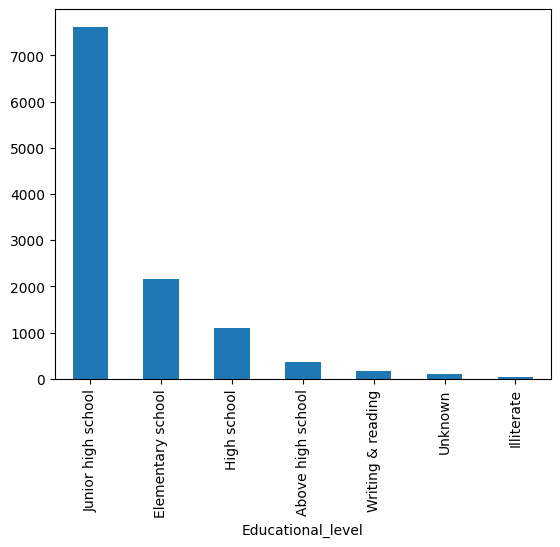

In [ ]:
RTA['Educational_level'].value_counts().plot(kind='bar')
plt.show()

<Figure size 600x500 with 0 Axes>

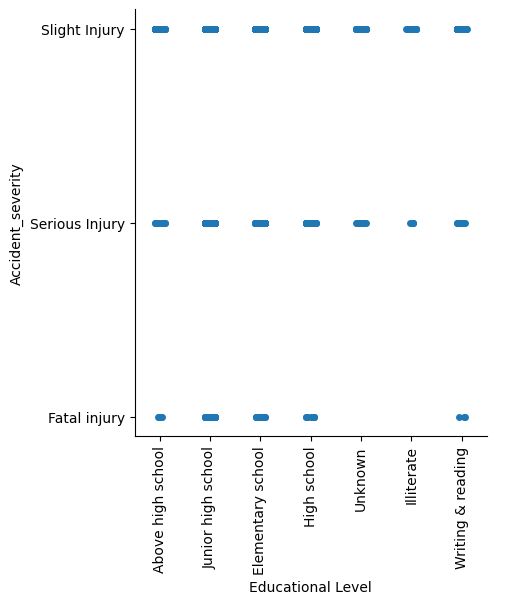

In [ ]:
plt.figure(figsize=(6,5))
sns.catplot(x = 'Educational_level', y = 'Accident_severity', data = RTA)
plt.xlabel("Educational Level")
plt.xticks(rotation = 90)
plt.show()

In [ ]:
RTA.select_dtypes(include=np.number).corr()

,Number_of_vehicles_involved,Number_of_casualties
Number_of_vehicles_involved,1.000000,0.213427
Number_of_casualties,0.213427,1.000000


Road_surface_type
Asphalt roads                       11296
Earth roads                           358
Gravel roads                          242
Other                                 167
Asphalt roads with some distress       81
Name: count, dtype: int64


<Figure size 600x500 with 0 Axes>

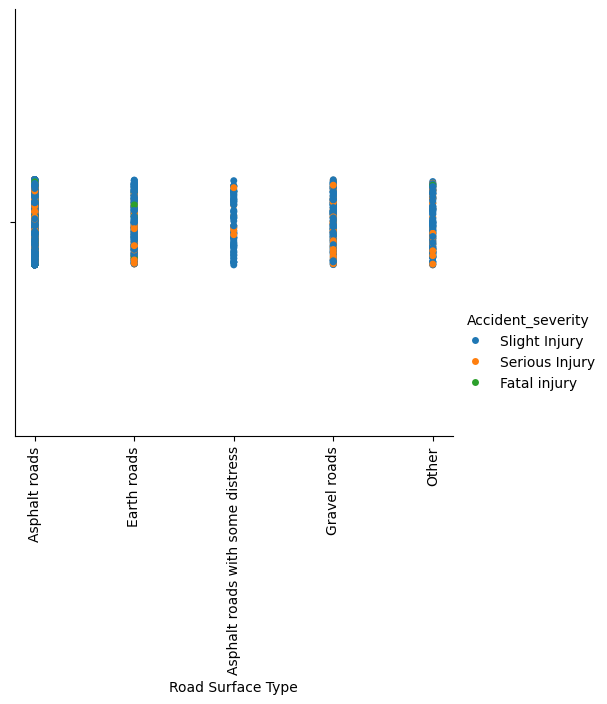

In [ ]:
print(RTA['Road_surface_type'].value_counts())

plt.figure(figsize=(6,5))
sns.catplot(x = 'Road_surface_type', hue = 'Accident_severity', data = RTA)
plt.xlabel("Road Surface Type")
plt.xticks(rotation = 90)
plt.show()

Road_surface_conditions
Dry                     9340
Wet or damp             2904
Snow                      70
Flood over 3cm. deep       2
Name: count, dtype: int64


<Figure size 600x500 with 0 Axes>

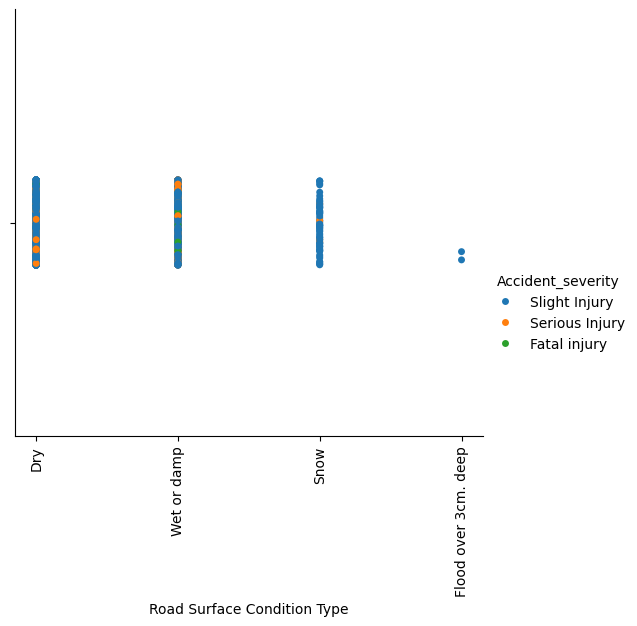

In [ ]:
print(RTA['Road_surface_conditions'].value_counts())

plt.figure(figsize=(6,5))
sns.catplot(x = 'Road_surface_conditions', hue = 'Accident_severity', data = RTA)
plt.xlabel("Road Surface Condition Type")
plt.xticks(rotation = 90)
plt.show()

In [ ]:
pivot_RTA = pd.pivot_table(data = RTA, index = 'Road_surface_conditions', columns= 'Accident_severity', aggfunc= 'count')

fatal_RTA = pivot_RTA['Road_surface_type']
fatal_RTA.fillna(0, inplace = True)
fatal_RTA['sum_of_injuries'] = fatal_RTA['Fatal injury'] + fatal_RTA['Serious Injury'] + fatal_RTA['Slight Injury']
fatal_RTA

Accident_severity,Fatal injury,Serious Injury,Slight Injury,sum_of_injuries
Road_surface_conditions,,,,
Dry,121.0,1312.0,7774.0,9207.0
Flood over 3cm. deep,0.0,0.0,2.0,2.0
Snow,0.0,4.0,65.0,69.0
Wet or damp,36.0,404.0,2426.0,2866.0


In [ ]:
fatal_RTA_Dry = (fatal_RTA.loc['Dry']/fatal_RTA.loc['Dry', 'sum_of_injuries'])*100
fatal_RTA_Dry

,Dry
Accident_severity,
Fatal injury,1.314217
Serious Injury,14.250027
Slight Injury,84.435755
sum_of_injuries,100.000000


In [ ]:
fatal_RTA_Snow = (fatal_RTA.loc['Wet or damp']/fatal_RTA.loc['Wet or damp', 'sum_of_injuries'])*100
fatal_RTA_Snow

,Wet or damp
Accident_severity,
Fatal injury,1.256106
Serious Injury,14.096301
Slight Injury,84.647592
sum_of_injuries,100.000000


In [ ]:
RTA.groupby('Road_surface_conditions')['Accident_severity'].count()

,Accident_severity
Road_surface_conditions,
Dry,9340
Flood over 3cm. deep,2
Snow,70
Wet or damp,2904


In [ ]:
RTA['Time'] = pd.to_datetime(RTA['Time'])

In [ ]:
Obj_cols = [col for col in RTA.columns if RTA[col].dtypes == 'object']
Obj_cols2 = [col for col in Obj_cols if col != 'Accident _severity']
Obj_cols2

['Day_of_week',
 'Age_band_of_driver',
 'Sex_of_driver',
 'Educational_level',
 'Vehicle_driver_relation',
 'Driving_experience',
 'Type_of_vehicle',
 'Owner_of_vehicle',
 'Service_year_of_vehicle',
 'Defect_of_vehicle',
 'Area_accident_occured',
 'Lanes_or_Medians',
 'Road_allignment',
 'Types_of_Junction',
 'Road_surface_type',
 'Road_surface_conditions',
 'Light_conditions',
 'Weather_conditions',
 'Type_of_collision',
 'Vehicle_movement',
 'Casualty_class',
 'Sex_of_casualty',
 'Age_band_of_casualty',
 'Casualty_severity',
 'Work_of_casuality',
 'Fitness_of_casuality',
 'Pedestrian_movement',
 'Cause_of_accident',
 'Accident_severity']

In [ ]:
new_RTA = RTA.copy()
new_RTA['Hour_of_day']= new_RTA['Time'].dt.hour
n_RTA = new_RTA.drop('Time', axis = 1)
n_RTA

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour_of_day
0,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,...,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury,17
1,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,17
2,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,...,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,...,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,...,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,No defect,...,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury,16
12312,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,No defect,...,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury,18
12313,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,No defect,...,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury,13
12314,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,No defect,...,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury,13


In [ ]:
# Data Visualization

In [ ]:
# Count Plot

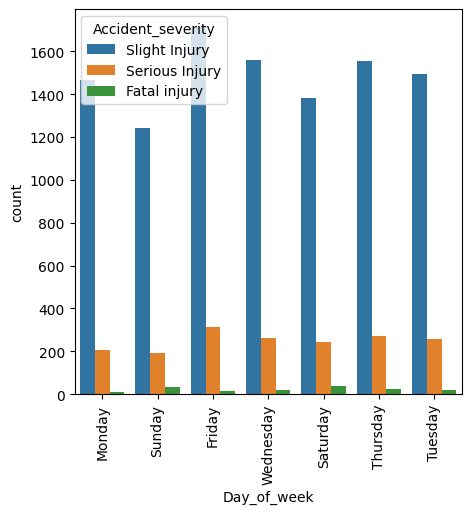

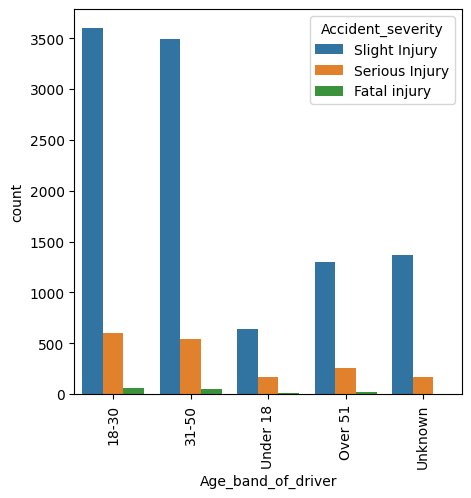

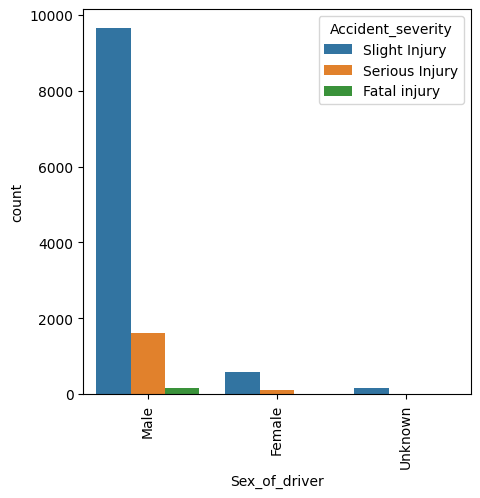

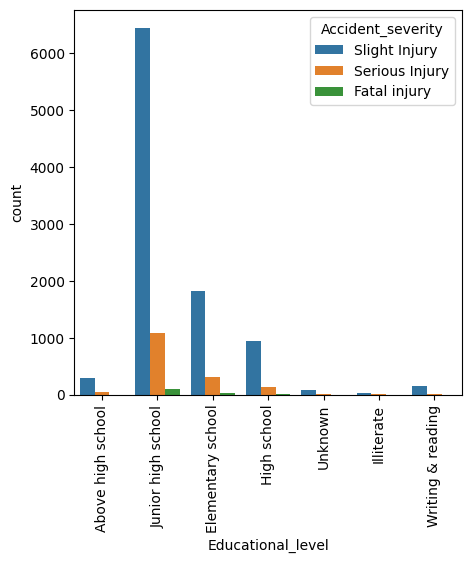

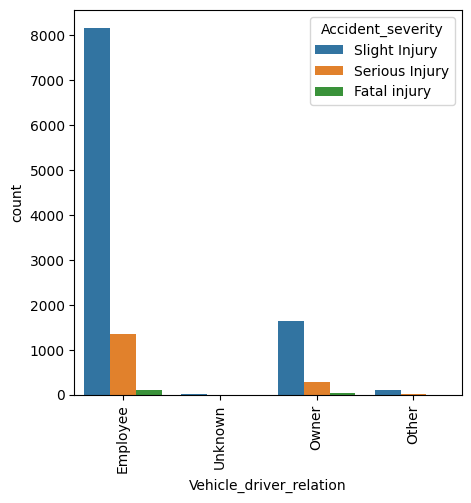

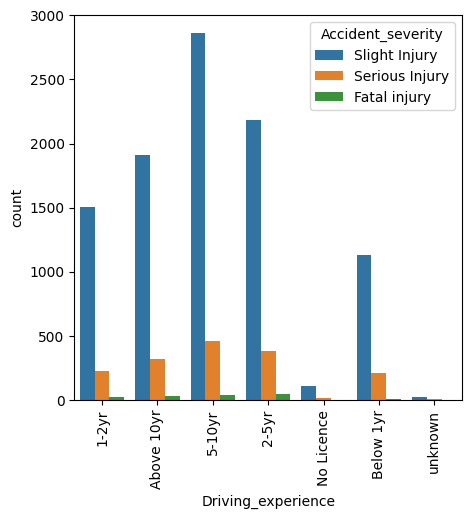

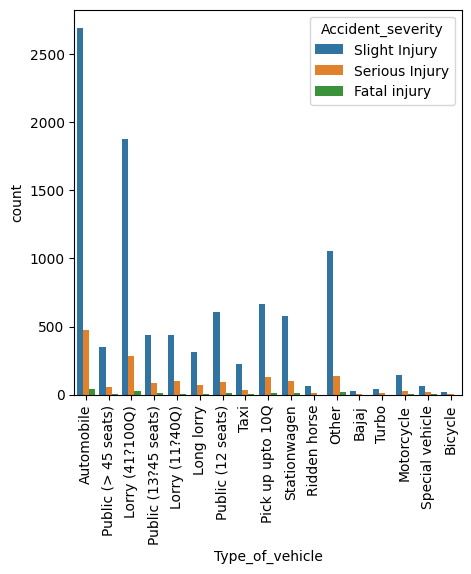

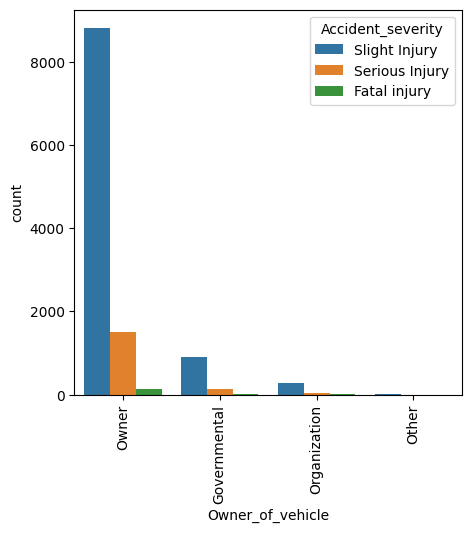

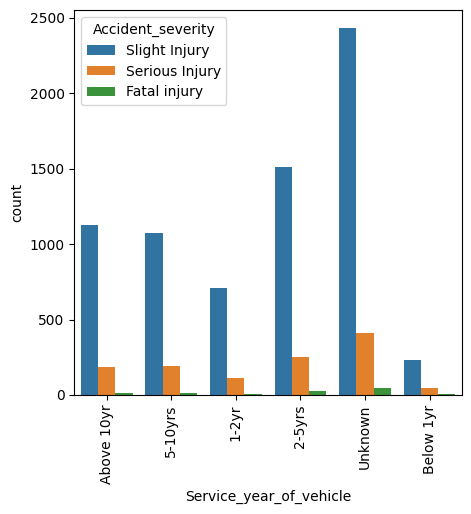

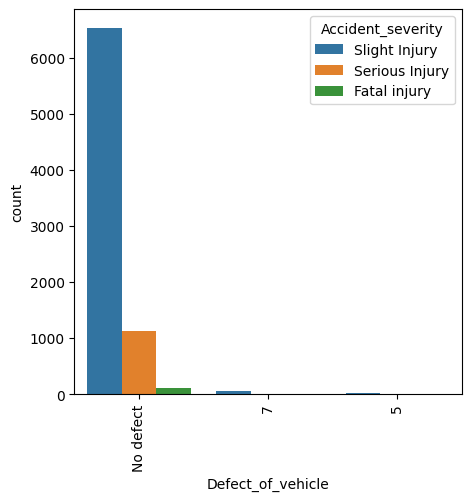

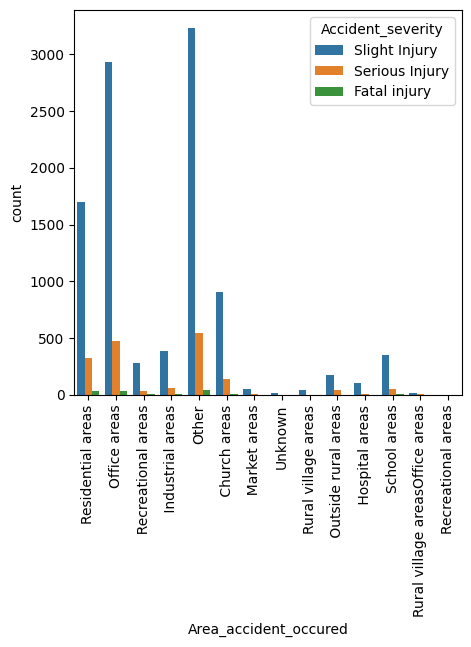

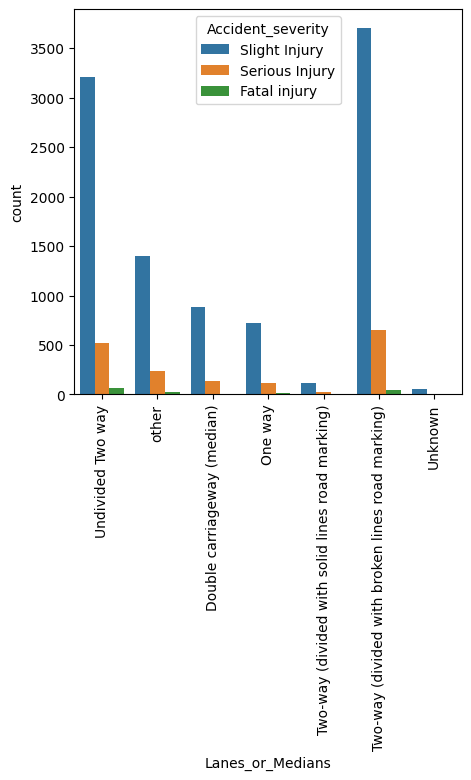

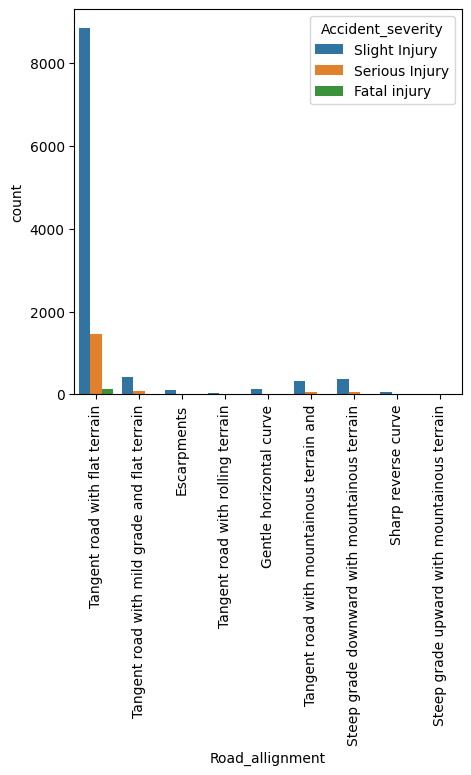

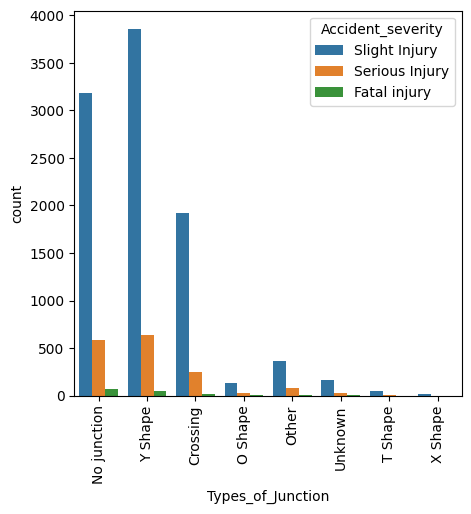

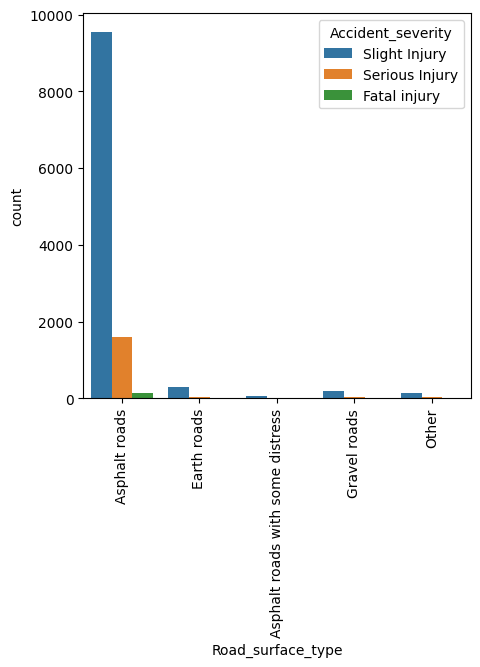

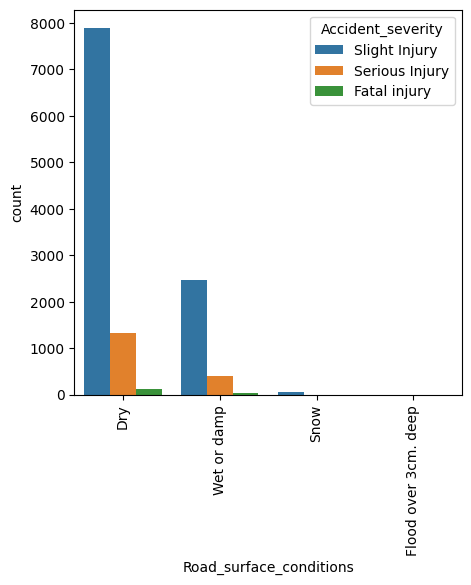

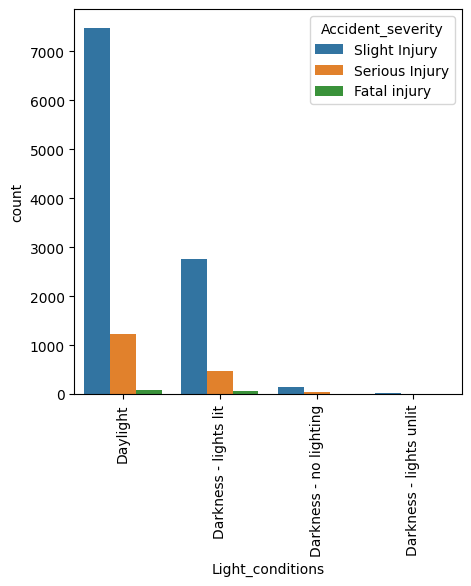

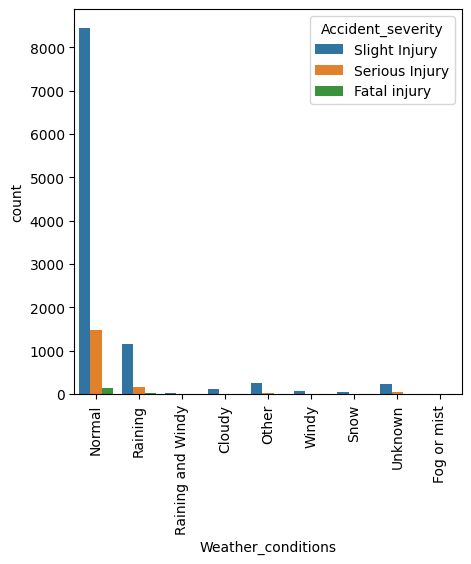

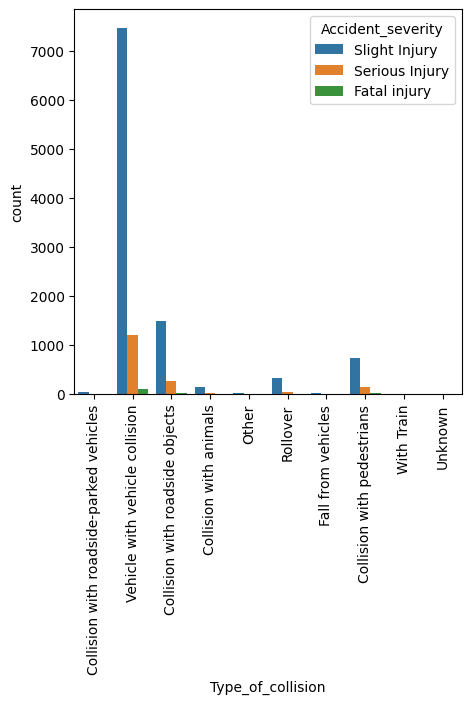

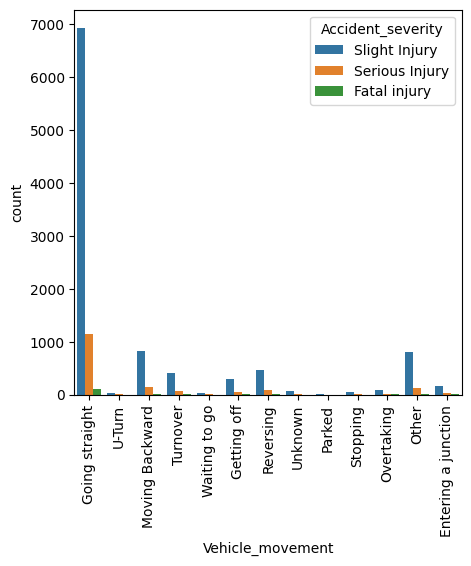

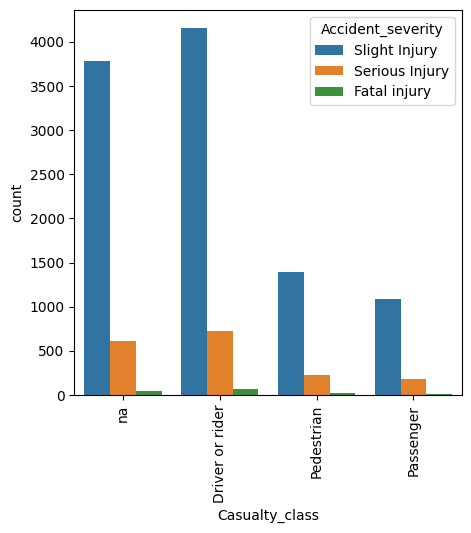

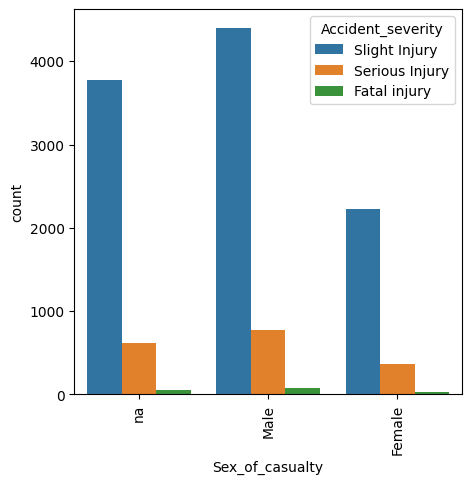

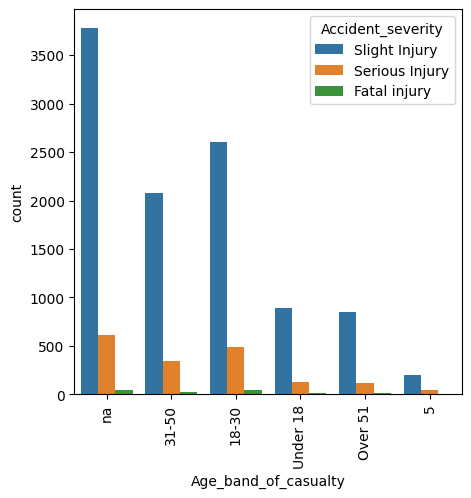

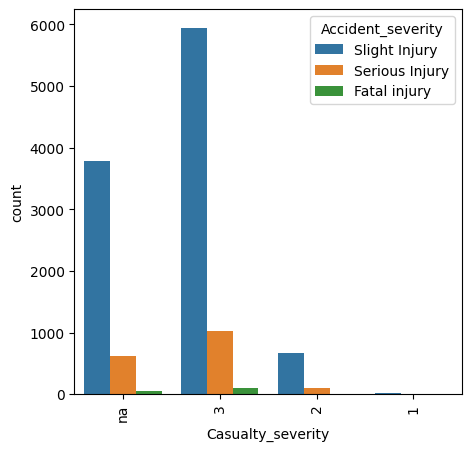

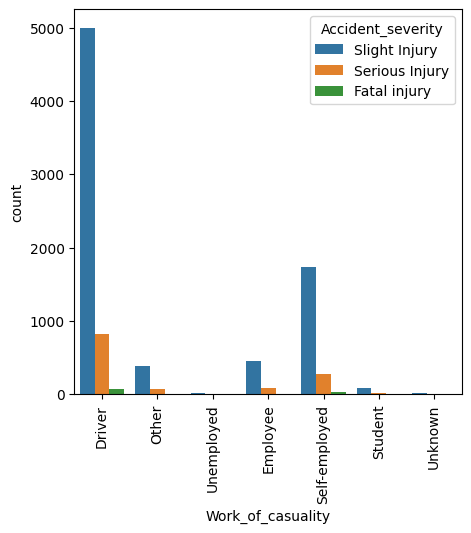

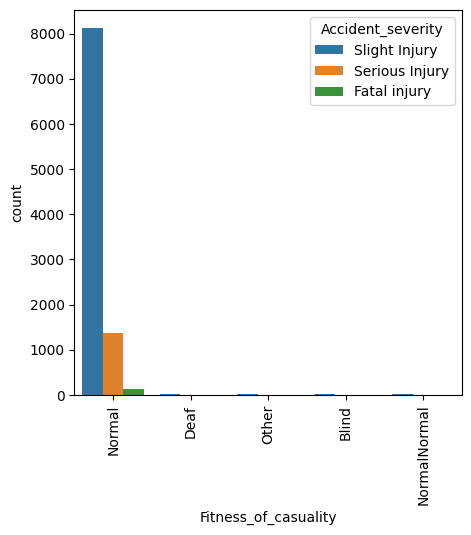

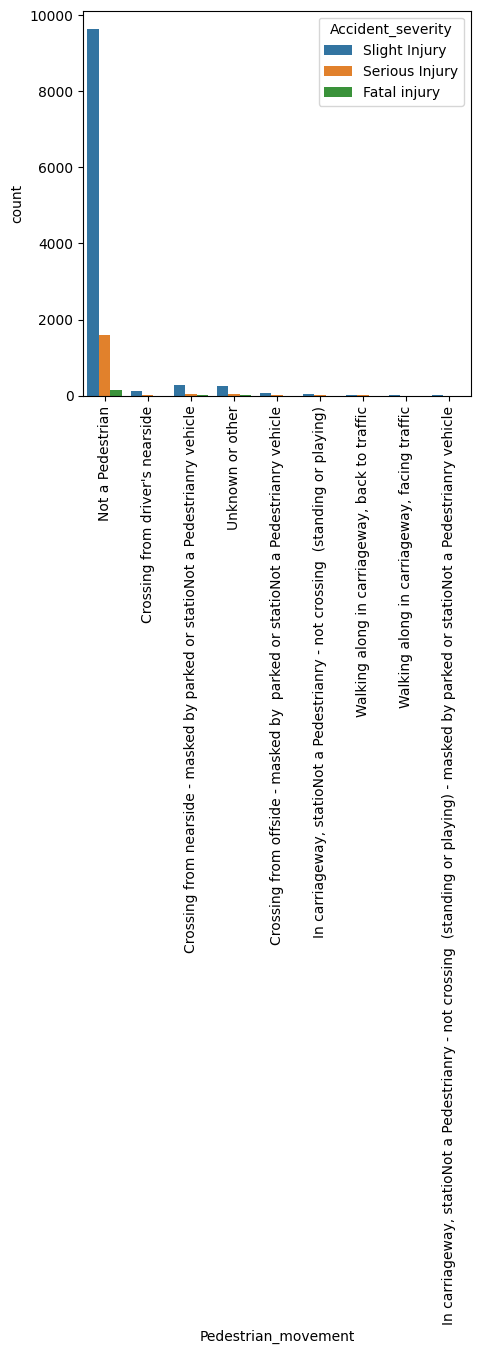

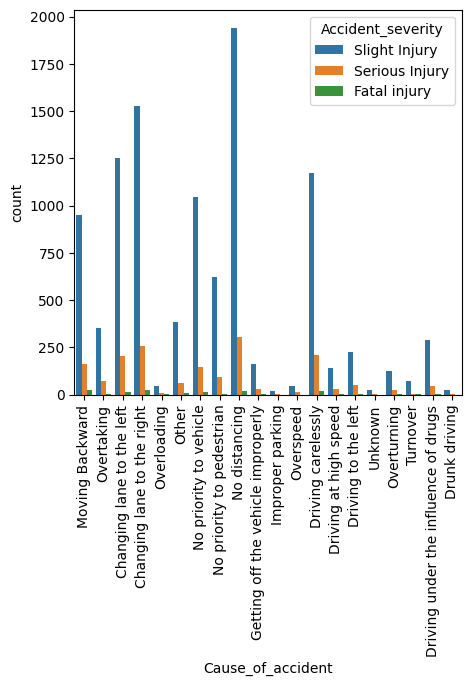

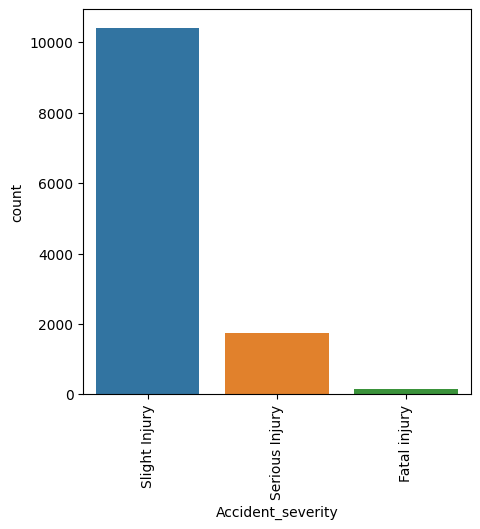

In [ ]:
def count_plot(col):
  n_RTA[col].value_counts()
  # plot the fogure of count plot
  plt.figure(figsize=(5,5))

  sns.countplot(x = col, hue = 'Accident_severity', data = n_RTA)
  plt.xlabel(f'{col}')
  plt.xticks(rotation = 90)
  plt.show()
for col in Obj_cols:
  count_plot(col)

In [ ]:
# Distribution Plot

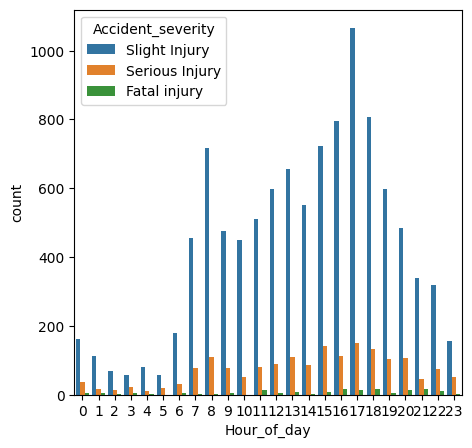

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x = 'Hour_of_day', hue = 'Accident_severity', data = n_RTA)
plt.show()

In [ ]:
# Number of attributes or features after removing null datasets

In [ ]:
features = ['Day_of_week', 'Type_of_vehicle','Number_of_ vehicles_involved', 'Number_of_casualities','Area_accident_occured','Types_of_Junction','Age_band_of_driver', 'Sex_of_driver','Educational_level', 'Vehicle_driver_relation','Driving_experience','Service_year_of_vehicle', 'Type_of_collision', 'Sex_of_casualty', 'Age_band_of_casualty', 'Cause_of_accident', 'Hour_of_day']
len(features)

17

In [ ]:
features = ['Day_of_week', 'Type_of_vehicle','Number_of_vehicles_involved', 'Number_of_casualties','Area_accident_occured','Types_of_Junction','Age_band_of_driver', 'Sex_of_driver','Educational_level', 'Vehicle_driver_relation','Driving_experience','Service_year_of_vehicle', 'Type_of_collision', 'Sex_of_casualty', 'Age_band_of_casualty', 'Cause_of_accident', 'Hour_of_day']
len(features)


17

In [ ]:
featureset_RTA = n_RTA[features]
target = n_RTA['Accident_severity']

In [ ]:
featureset_RTA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Day_of_week                  12316 non-null  object
 1   Type_of_vehicle              11366 non-null  object
 2   Number_of_vehicles_involved  12316 non-null  int64 
 3   Number_of_casualties         12316 non-null  int64 
 4   Area_accident_occured        12077 non-null  object
 5   Types_of_Junction            11429 non-null  object
 6   Age_band_of_driver           12316 non-null  object
 7   Sex_of_driver                12316 non-null  object
 8   Educational_level            11575 non-null  object
 9   Vehicle_driver_relation      11737 non-null  object
 10  Driving_experience           11487 non-null  object
 11  Service_year_of_vehicle      8388 non-null   object
 12  Type_of_collision            12161 non-null  object
 13  Sex_of_casualty              12

In [ ]:
feature_RTA = featureset_RTA.copy()

In [ ]:
# Let us fill the non-null values with 'unknowns'

In [ ]:
feature_RTA['Service_year_of_vehicle'] = feature_RTA['Service_year_of_vehicle'].fillna('Unknown')
feature_RTA['Types_of_Junction'] = feature_RTA['Types_of_Junction'].fillna('Unknown')
feature_RTA['Area_accident_occured'] = feature_RTA['Area_accident_occured'].fillna('Unknown')
feature_RTA['Driving_experience'] = feature_RTA['Driving_experience'].fillna('Unknown')
feature_RTA['Type_of_vehicle'] = feature_RTA['Type_of_vehicle'].fillna('Unknown')
feature_RTA['Vehicle_driver_relation'] = feature_RTA['Vehicle_driver_relation'].fillna('Unknown')
feature_RTA['Type_of_collision'] = feature_RTA['Type_of_collision'].fillna('Unknown')
feature_RTA['Educational_level'] = feature_RTA['Educational_level'].fillna('Unknown')

In [ ]:
feature_RTA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Day_of_week                  12316 non-null  object
 1   Type_of_vehicle              12316 non-null  object
 2   Number_of_vehicles_involved  12316 non-null  int64 
 3   Number_of_casualties         12316 non-null  int64 
 4   Area_accident_occured        12316 non-null  object
 5   Types_of_Junction            12316 non-null  object
 6   Age_band_of_driver           12316 non-null  object
 7   Sex_of_driver                12316 non-null  object
 8   Educational_level            12316 non-null  object
 9   Vehicle_driver_relation      12316 non-null  object
 10  Driving_experience           12316 non-null  object
 11  Service_year_of_vehicle      12316 non-null  object
 12  Type_of_collision            12316 non-null  object
 13  Sex_of_casualty              12

In [ ]:
X = feature_RTA[features]
y = target

In [ ]:
# For on_hot encoding let us use Pandas get_dummies method

In [ ]:
encoded_RTA = pd.get_dummies(X, drop_first=True)
encoded_RTA.shape

(12316, 108)

In [ ]:
# SMOTE Balancing

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from sklearn.feature_selection import chi2
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report,f1_score

In [ ]:
lb = LabelEncoder()
lb.fit(y)
y_encoded = lb.transform(y)
print("Encoded labels:", lb.classes_)
y_en = pd.Series(y_encoded)

Encoded labels: ['Fatal injury' 'Serious Injury' 'Slight Injury']


In [ ]:
# Mutual info classif to check informative features

In [ ]:
mi_calc = mutual_info_classif(encoded_RTA, y_en, random_state=42)

In [ ]:
mi_RTA = pd.DataFrame({'columns': encoded_RTA.columns, 'MI_score': mi_calc})
mi_RTA.sort_values(by = 'MI_score', ascending = False).head(15)

,columns,MI_score
50,Sex_of_driver_Male,0.008984
63,Driving_experience_Above 10yr,0.008694
0,Number_of_vehicles_involved,0.008023
40,Types_of_Junction_O Shape,0.007651
73,Type_of_collision_Collision with pedestrians,0.006591
88,Age_band_of_casualty_na,0.006188
1,Number_of_casualties,0.006144
22,Type_of_vehicle_Stationwagen,0.006075
2,Hour_of_day,0.005917
28,Area_accident_occured_ Hospital areas,0.005677


In [ ]:
# Feature Selection method using chi2 for categorical output, categorical input


In [ ]:
fs = SelectKBest(chi2, k=50)
X_new = fs.fit_transform(encoded_RTA, y_en)
X_new.shape
cols = fs.get_feature_names_out()

In [ ]:
fs_RTA = pd.DataFrame(X_new, columns=cols)
fs_RTA.head()

,Number_of_vehicles_involved,Number_of_casualties,Hour_of_day,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Type_of_vehicle_Long lorry,Type_of_vehicle_Lorry (11?40Q),Type_of_vehicle_Lorry (41?100Q),Type_of_vehicle_Other,...,Age_band_of_casualty_Under 18,Cause_of_accident_Driving to the left,Cause_of_accident_Moving Backward,Cause_of_accident_No distancing,Cause_of_accident_No priority to pedestrian,Cause_of_accident_No priority to vehicle,Cause_of_accident_Overloading,Cause_of_accident_Overspeed,Cause_of_accident_Overtaking,Cause_of_accident_Turnover
0,2,2,17,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,2,2,17,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2,2,17,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2,2,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,2,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
n_cat_index = list(range(3,30))
smote = SMOTENC(categorical_features = n_cat_index, random_state = 42)
X_n, y_n = smote.fit_resample(fs_RTA, y_en)
X_n.shape, y_n.shape

((31245, 50), (31245,))

In [ ]:
n_cat_index = list(range(3,50))
smote = SMOTENC(categorical_features = n_cat_index, random_state = 42)
X_n, y_n = smote.fit_resample(fs_RTA, y_en)
X_n.shape, y_n.shape

((31245, 50), (31245,))

In [ ]:
y_n.value_counts()

,count
2,10415
1,10415
0,10415


In [ ]:
# Data Spliting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_n, y_n, test_size = 0.2, random_state = 42)

In [ ]:
# Model Implementation

In [ ]:
# Random Forest Algorithm

In [ ]:
rf = RandomForestClassifier(n_estimators=800, max_depth=20, random_state=42)
rf.fit(X_train, y_train)
predics = rf.predict(X_test)

In [ ]:
rf.score(X_train, y_train)

0.9478716594655144

In [ ]:
# Classification Report and Confusion Matrix of Random Forest

In [ ]:
classif_re = classification_report(y_test, predics)
print(classif_re)

              precision    recall  f1-score   support

           0       0.76      0.63      0.69      2085
           1       0.64      0.62      0.63      2100
           2       0.84      1.00      0.91      2064

    accuracy                           0.75      6249
   macro avg       0.74      0.75      0.74      6249
weighted avg       0.74      0.75      0.74      6249



In [ ]:
from sklearn.metrics import confusion_matrix
cm1= confusion_matrix(y_test, predics)
print(cm1)

[[1315  741   29]
 [ 423 1307  370]
 [   0    1 2063]]


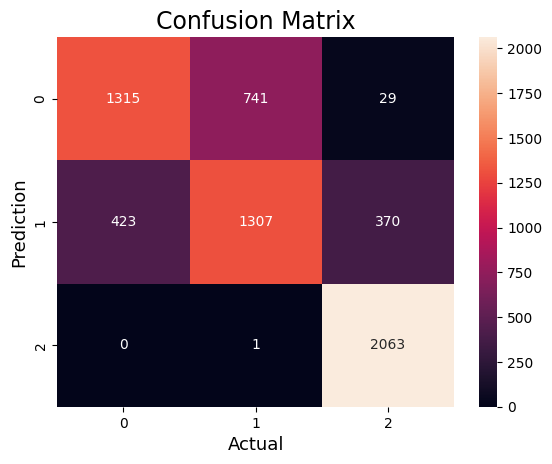

In [ ]:
sns.heatmap(cm1, annot=True, fmt='g')
plt.ylabel('Prediction', fontsize = 13)
plt.xlabel('Actual', fontsize = 13)
plt.title('Confusion Matrix', fontsize = 17)
plt.show()

In [ ]:
f1score = f1_score(y_test, predics, average='weighted')
print(f1score)
RF_score = f1score

0.742360522752452


In [ ]:
# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
d_tree = DecisionTreeClassifier(random_state = 42)
d_tree.fit(X_train, y_train)
predict_dt = d_tree.predict(X_test)
score_dt_tree = d_tree.score(X_train, y_train)
print("Model Accuracy:", score_dt_tree)

Model Accuracy: 0.9988398143702992


In [ ]:
# Classification report for Decision Report

In [ ]:
classif_report_DT = classification_report(y_test, predict_dt)
print(classif_report_DT)

              precision    recall  f1-score   support

           0       0.77      0.74      0.76      2085
           1       0.63      0.67      0.65      2100
           2       0.85      0.84      0.84      2064

    accuracy                           0.75      6249
   macro avg       0.75      0.75      0.75      6249
weighted avg       0.75      0.75      0.75      6249



In [ ]:
# Confusion Matrix for DT

In [ ]:
from sklearn.metrics import confusion_matrix
cm2= confusion_matrix(y_test, predict_dt)
print(cm2)

[[1539  519   27]
 [ 411 1410  279]
 [  38  295 1731]]


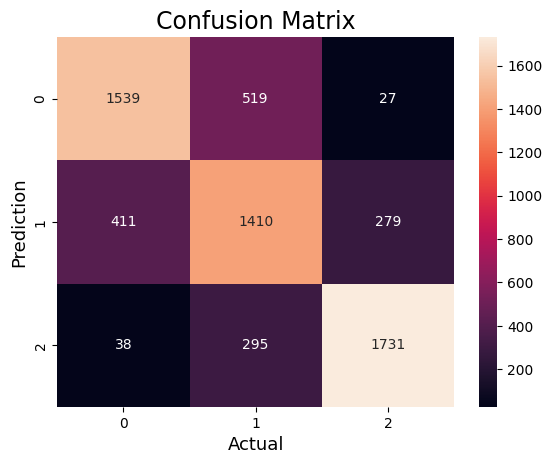

In [ ]:
sns.heatmap(cm2, annot=True, fmt='g')
plt.ylabel('Prediction', fontsize = 13)
plt.xlabel('Actual', fontsize = 13)
plt.title('Confusion Matrix', fontsize = 17)
plt.show()

In [ ]:
# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_reg = LogisticRegression(C=10)
lr_reg.fit(X_train, y_train)
predict_lr = lr_reg.predict(X_test)
score_lr_reg = lr_reg.score(X_test, y_test)
print("Model Accuracy:", score_lr_reg)

Model Accuracy: 0.7007521203392543


In [ ]:
# Classifiction Report for Logistic Regression

In [ ]:
classif_report_LR = classification_report(y_test, predict_lr)
print(classif_report_LR)

              precision    recall  f1-score   support

           0       0.65      0.62      0.63      2085
           1       0.57      0.49      0.53      2100
           2       0.84      1.00      0.91      2064

    accuracy                           0.70      6249
   macro avg       0.69      0.70      0.69      6249
weighted avg       0.69      0.70      0.69      6249



In [ ]:
# Confusion Matrix for Logistic Regression

In [ ]:
from sklearn.metrics import confusion_matrix
cm3= confusion_matrix(y_test, predict_lr)
print(cm3)

[[1285  773   27]
 [ 690 1035  375]
 [   4    1 2059]]


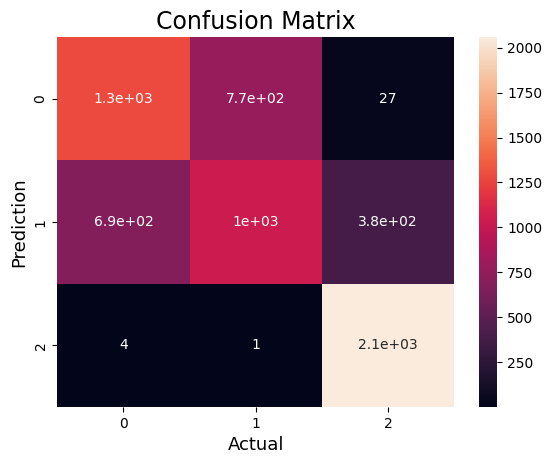

In [ ]:
sns.heatmap(cm3, annot=True)
plt.ylabel('Prediction', fontsize = 13)
plt.xlabel('Actual', fontsize = 13)
plt.title('Confusion Matrix', fontsize = 17)
plt.show()

In [ ]:
# SVC Support Vector Classifier

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC

SVM_cr = OneVsRestClassifier(BaggingClassifier(SVC(C=10,kernel = 'rbf', random_state = 9, probability = True), n_jobs=-1))
SVM_cr.fit(X_train, y_train)
predict_svm = SVM_cr.predict(X_test)
score_svm_cr = SVM_cr.score(X_test, y_test)
print("Model Accuracy:", score_svm_cr)


Model Accuracy: 0.7177148343734998


In [ ]:
# Classification report for SVM

In [ ]:
classif_report_SVM = classification_report(y_test, predict_svm)
print(classif_report_SVM)

              precision    recall  f1-score   support

           0       0.71      0.57      0.63      2085
           1       0.59      0.58      0.59      2100
           2       0.83      1.00      0.91      2064

    accuracy                           0.72      6249
   macro avg       0.71      0.72      0.71      6249
weighted avg       0.71      0.72      0.71      6249



In [ ]:
# Confusion Matrix for SVM

In [ ]:
from sklearn.metrics import confusion_matrix
cm4= confusion_matrix(y_test, predict_svm)
print(cm4)

[[1195  860   30]
 [ 495 1226  379]
 [   0    0 2064]]


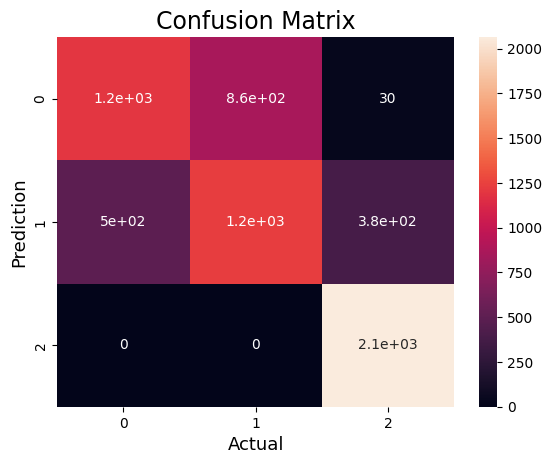

In [ ]:
sns.heatmap(cm4, annot=True)
plt.ylabel('Prediction', fontsize = 13)
plt.xlabel('Actual', fontsize = 13)
plt.title('Confusion Matrix', fontsize = 17)
plt.show()

In [ ]:
# KNN Algorithm

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_b = KNeighborsClassifier(n_neighbors=5, n_jobs = -1)
knn_b.fit(X_train, y_train)
predict_knn = knn_b.predict(X_test)
score_knn_b = knn_b.score(X_test, y_test)
print("Model Accuracy:", score_knn_b)

Model Accuracy: 0.7258761401824292


In [ ]:
# Classification report for KNN

In [ ]:
classification_report_knn = classification_report(y_test, predict_knn)
print(classification_report_knn)

              precision    recall  f1-score   support

           0       0.70      0.70      0.70      2085
           1       0.65      0.50      0.57      2100
           2       0.80      0.98      0.88      2064

    accuracy                           0.73      6249
   macro avg       0.71      0.73      0.72      6249
weighted avg       0.71      0.73      0.71      6249



In [ ]:
# Confusion Matrix for KNN

In [ ]:
from sklearn.metrics import confusion_matrix
cm5= confusion_matrix(y_test, predict_knn)
print(cm5)

[[1457  542   86]
 [ 624 1058  418]
 [   3   40 2021]]


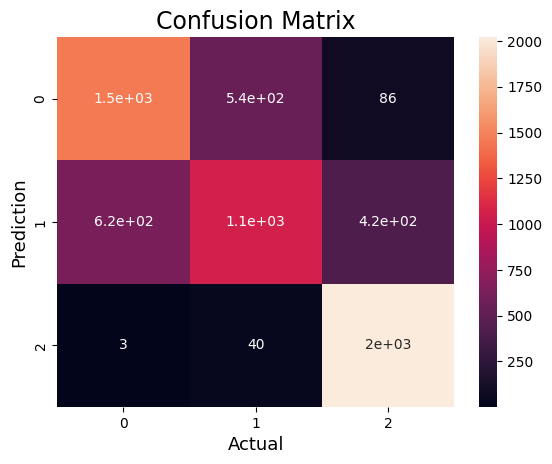

In [ ]:
sns.heatmap(cm5, annot = True)
plt.ylabel('Prediction', fontsize = 13)
plt.xlabel('Actual', fontsize = 13)
plt.title('Confusion Matrix', fontsize = 17)
plt.show()

In [ ]:
# Comparison of Algorithms

<Figure size 1000x700 with 0 Axes>

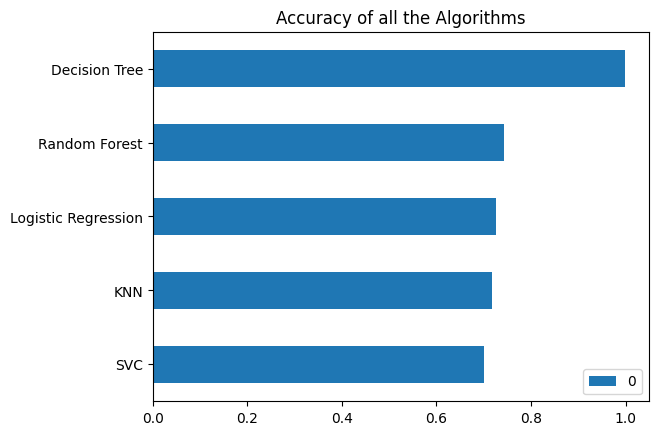

In [ ]:
Final_model_accuracy = pd.DataFrame(data=[RF_score, score_dt_tree, score_knn_b, score_lr_reg, score_svm_cr], index = ['Random Forest', 'Decision Tree', 'Logistic Regression', 'SVC', 'KNN'])
fig = plt.figure(figsize=(10,7))
Final_model_accuracy.sort_values(by=0).plot.barh()
plt.title('Accuracy of all the Algorithms')
plt.show()